# Some properties of the Hartree-Fock method


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%pip install pyscf
from pyscf import gto, scf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 MB 20.6 MB/s eta 0:00:00


## Adding more gaussians
When does adding more functions to our STO-nG basis start yielding diminishing returns?


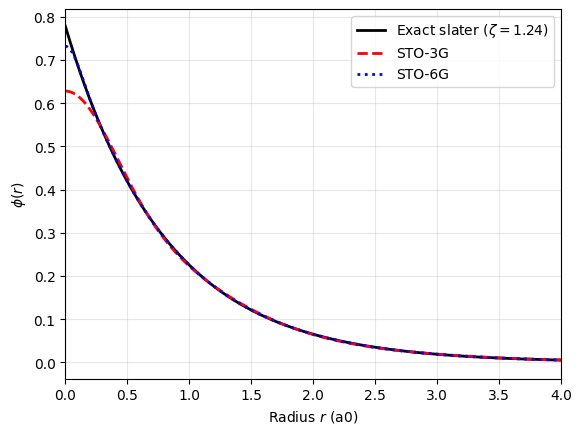

In [3]:
# define a spatial grid along the radius
r = np.linspace(0.0, 5.0, 500)

# exact Slater orbital
zeta = 1.24
phi_exact = (zeta**3 / np.pi)**0.5 * np.exp(-zeta * r)

# STO-3G parameters for Hydrogen 1s
alpha_3g = np.array([3.42525091, 0.62391373, 0.16885540])
d_3g = np.array([0.15432897, 0.53532814, 0.44463454])

phi_3g = np.zeros_like(r)
for a, d in zip(alpha_3g, d_3g):
    N = (2 * a / np.pi)**0.75  # The normalization constant we derived!
    phi_3g += d * N * np.exp(-a * r**2)

# STO-6G parameters for Hydrogen 1s
# using the exponents from problem set
alpha_6g = np.array([0.3552322122E+02, 0.6513143725E+01, 0.1822142904E+01, 0.6259552659E+00, 0.2430767471E+00, 0.1001124280E+00])
d_6g = np.array([0.9163596281E-02, 0.4936149294E-01, 0.1685383049E+00, 0.3705627997E+00, 0.4164915298E+00, 0.1303340841E+00])

phi_6g = np.zeros_like(r)
for a, d in zip(alpha_6g, d_6g):
    N = (2 * a / np.pi)**0.75
    phi_6g += d * N * np.exp(-a * r**2)

# plotting
plt.plot(r, phi_exact, 'k-', lw=2, label='Exact slater ($\\zeta=1.24$)')
plt.plot(r, phi_3g, 'r--', lw=2, label='STO-3G')
plt.plot(r, phi_6g, color="b", linestyle=":", lw=2, label='STO-6G')

plt.xlabel("Radius $r$ (a0)")
plt.ylabel("$\\phi(r)$")
plt.xlim(0, 4)
plt.legend()
plt.grid(alpha=0.3)

## Double zeta basis sets
Double Zeta (DZ) basis sets provides a "tight" and "diffuse" function to let the electron density dynamically expand or contract based on its chemical environment. This is a smarter way to satisy our variational method intuition that adding more basis functions should decrease the energy until it converges to the exact Hartere-Fock limit.

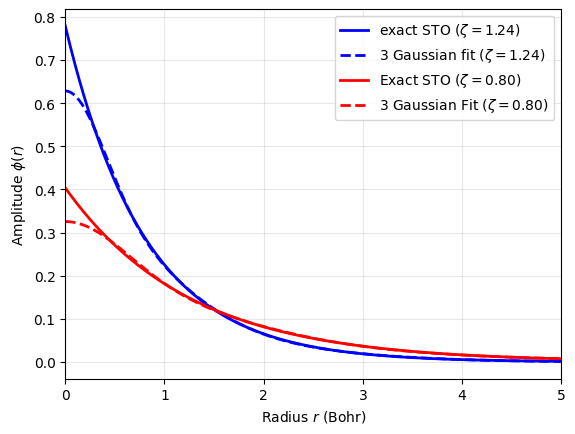

In [4]:
r_dz = np.linspace(0.0, 6.0, 500)

# define two different STO effective nuclear charges
zeta_tight = 1.24   # standard H atom size
zeta_diffuse = 0.80 # expanded H atom (e.g. if it gains partial negative charge)

# exact STOs
sto_tight = (zeta_tight**3 / np.pi)**0.5 * np.exp(-zeta_tight * r_dz)
sto_diffuse = (zeta_diffuse**3 / np.pi)**0.5 * np.exp(-zeta_diffuse * r_dz)

# the universal unscaled 1s Gaussian primitives (zeta = 1.0)
alpha_unscaled = np.array([2.22766, 0.405771, 0.109818])
d_unscaled = np.array([0.15432897, 0.53532814, 0.44463454])

# scale the exponents by zeta^2 to create our two basis functions
alpha_tight = alpha_unscaled * (zeta_tight**2)
alpha_diffuse = alpha_unscaled * (zeta_diffuse**2)

phi_tight = np.zeros_like(r_dz)
phi_diffuse = np.zeros_like(r_dz)

# Build the tight Gaussian fit with 3 functions
for a, d in zip(alpha_tight, d_unscaled):
    N = (2 * a / np.pi)**0.75
    phi_tight += d * N * np.exp(-a * r_dz**2)

# Build the diffuse Gaussian fit with 3 functions
for a, d in zip(alpha_diffuse, d_unscaled):
    N = (2 * a / np.pi)**0.75
    phi_diffuse += d * N * np.exp(-a * r_dz**2)

# plotting
plt.plot(r_dz, sto_tight, 'b-', lw=2, label='exact STO ($\\zeta=1.24$)')
plt.plot(r_dz, phi_tight, 'b--', lw=2, label='3 Gaussian fit ($\\zeta=1.24$)')

plt.plot(r_dz, sto_diffuse, 'r-', lw=2, label='Exact STO ($\\zeta=0.80$)')
plt.plot(r_dz, phi_diffuse, 'r--', lw=2, label='3 Gaussian Fit ($\\zeta=0.80$)')

plt.xlabel("Radius $r$ (Bohr)")
plt.ylabel("Amplitude $\\phi(r)$")
plt.xlim(0, 5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Super simple PySCF

In [6]:

# define the molecule
mol = gto.M(atom='H 0 0 0; H 0 0 0.74', basis='cc-pvdz', unit='angstrom')

# det up the RHF object
mf = scf.RHF(mol)

# run the calculation
energy = mf.run(verbose=4)



******** <class 'pyscf.scf.hf.RHF'> ********
method = RHF
initial guess = minao
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 50
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmputqef2fy
max_memory 4000 MB (current use 174 MB)
Set gradient conv threshold to 3.16228e-05
Initial guess from minao.
init E= -0.812083679939727
  HOMO = -0.554565732564958  LUMO = 0.155207455491933
cycle= 1 E= -1.12773421671327  delta_E= -0.316  |g|= 0.0451  |ddm|= 0.706
  HOMO = -0.599776376507856  LUMO = 0.193233599759233
cycle= 2 E= -1.12867333647629  delta_E= -0.000939  |g|= 0.00705  |ddm|= 0.0427
  HOMO = -0.592585612088552  LUMO = 0.197336841534647
cycle= 3 E= -1.12870004279955  delta_E= -2.67e-05  |g|= 0.000367  |ddm|= 0.00928
  HOMO = -0.592406179645731  LUMO = 0.19743921699556
cycle= 4 E= -1.12870009355196  delta_E= -5.08e-08 

## Basis set convergence
As we increase the number of basis functions (in a smart way by using double zeta, triple zeta), the energy monotonically decreases!

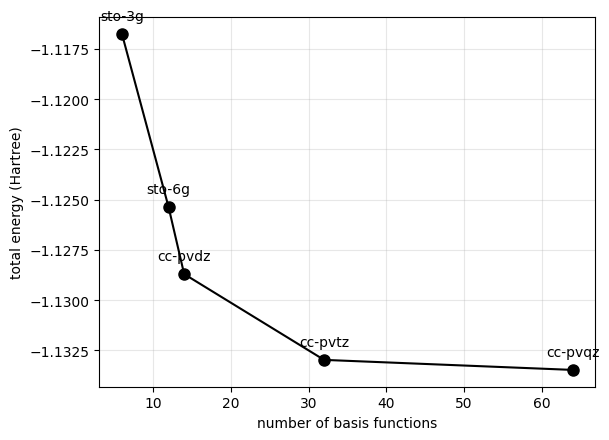

In [7]:
bases = ['sto-3g', 'sto-6g', 'cc-pvdz', 'cc-pvtz', 'cc-pvqz']
n_funcs = []
energies = []

for b in bases:
    # H2 at equilibrium geometry
    mol = gto.M(atom='H 0 0 0; H 0 0 0.74', basis=b, unit='angstrom')
    mf = scf.RHF(mol).run(verbose=0)

    n_funcs.append(mol.npgto_nr())
    energies.append(mf.e_tot)

plt.plot(n_funcs, energies, 'ko-', markersize=8)

for i, txt in enumerate(bases):
    plt.annotate(txt, (n_funcs[i], energies[i]),
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.xlabel("number of basis functions")
plt.ylabel("total energy (Hartree)")
plt.grid(alpha=0.3)
plt.show()

# Success of HF: equilibrium structure and bonding!

As we are seeing in the problem set, Hartree-Fock is surprisingly good at describing bonding and equilbrium stucture, even when using a tiny basis! Here are some slightly more compplicated examples: H2O and benzene. We can understand certain aspects of whether the bonding is correctly described by looking at quantities like partial charges, molecular dipole moments, and orbital degeneracies.

In [ ]:
# define the water molecule
mol_h2o = gto.M(
    atom='''
    O  0.00000  0.00000  0.11730
    H  0.00000  0.75720 -0.46920
    H  0.00000 -0.75720 -0.46920
    ''',
    basis='sto-3g',
    verbose=0
)

# run Hartree-Fock
mf_h2o = scf.RHF(mol_h2o).run()

# analyze Bonding via partial charges and dipole moment of molecule
print(f"Total Energy: {mf_h2o.e_tot:.4f} Hartree")

print("\nmulliken partial charges:")
pop, charges = mf_h2o.mulliken_pop(verbose=0)
for i, atom in enumerate(mol_h2o.elements):
    print(f"  {atom} atom: {charges[i]:+.3f} e-")

print("\ndipole moment (shows the bent structure is polar):")
dipole = mf_h2o.dip_moment(mol_h2o, mf_h2o.make_rdm1(), verbose=0)
print(f"  Total Dipole: {np.linalg.norm(dipole)} Debye")


# now define benzene
print("\n\n now benzene")
mol_benzene = gto.M(
    atom='''
    C   0.00000   1.39700   0.00000
    C   1.20980   0.69850   0.00000
    C   1.20980  -0.69850   0.00000
    C   0.00000  -1.39700   0.00000
    C  -1.20980  -0.69850   0.00000
    C  -1.20980   0.69850   0.00000
    H   0.00000   2.48100   0.00000
    H   2.14860   1.24050   0.00000
    H   2.14860  -1.24050   0.00000
    H   0.00000  -2.48100   0.00000
    H  -2.14860  -1.24050   0.00000
    H  -2.14860   1.24050   0.00000
    ''',
    basis='ccpvdz',
    verbose=0
)

# run Hartree-Fock
mf_benzene = scf.RHF(mol_benzene).run()

print(f"Total Energy: {mf_benzene.e_tot:.4f} Hartree")

print("\nmulliken partial charges (shows perfect symmetry):")
pop, charges = mf_benzene.mulliken_pop(verbose=0)
print(f"  Average C charge: {sum(charges[0:6])/6:+.3f} e-")
print(f"  Average H charge: {sum(charges[6:12])/6:+.3f} e-")

print("\ndipole moment (perfectly non-polar):")
dipole_vec_bz = mf_benzene.dip_moment(mol_benzene, mf_benzene.make_rdm1(), verbose=0)
print(f"  Total Dipole: {np.linalg.norm(dipole_vec_bz)} Debye")

print("\nfrontier orbital energies (shows the degenerate pi-system):")
evals = mf_benzene.mo_energy
print(f"  HOMO-1 Energy: {evals[19]:.3f} Hartree")
print(f"  HOMO   Energy: {evals[20]:.3f} Hartree (degenerate)")
print(f"  LUMO   Energy: {evals[21]:.3f} Hartree")
print(f"  LUMO+1 Energy: {evals[22]:.3f} Hartree (degenerate)")

Total Energy: -74.9630 Hartree

mulliken partial charges:
  O atom: -0.366 e-
  H atom: +0.183 e-
  H atom: +0.183 e-

dipole moment (shows the bent structure is polar):
  Total Dipole: 1.7253065800915413 Debye


 now benzene
Total Energy: -230.7219 Hartree

mulliken partial charges (shows perfect symmetry):
  Average C charge: -0.025 e-
  Average H charge: +0.025 e-

dipole moment (perfectly non-polar):
  Total Dipole: 3.26594863341781e-13 Debye

frontier orbital energies (shows the degenerate pi-system):
  HOMO-1 Energy: -0.333 Hartree
  HOMO   Energy: -0.333 Hartree (degenerate)
  LUMO   Energy: 0.137 Hartree
  LUMO+1 Energy: 0.137 Hartree (degenerate)
